In [1]:
import os
import random
import numpy as np
import pandas as pd
import torch
from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import BaseCallback, CheckpointCallback, CallbackList
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.utils import set_random_seed

import matplotlib.pyplot as plt
import importlib
import modified_pong_env
from modified_pong_env import ModifiedPongEnv
import pong_baselines
from pong_baselines import action_heuristic_predictive

SEED = 2026
N_ACTION_BINS = 11
MAX_EPISODE_DECISIONS = 50
TOTAL_TIMESTEPS = 500_000
EVAL_FREQ = 10_000
N_EVAL_EPISODES_CALLBACK = 100
N_FINAL_EVAL_EPISODES = 300

MODEL_DIR = "ppo_modified_pong_models"
LOG_DIR = "ppo_modified_pong_logs"

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)

def set_all_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    set_random_seed(seed)

set_all_seeds(SEED)

In [2]:
# Environment build
def make_train_env(seed=SEED):
    env = ModifiedPongEnv(
        n_action_bins=N_ACTION_BINS,
        render_mode=None,
        max_episode_decisions=MAX_EPISODE_DECISIONS,
    )
    env = Monitor(
        env,
        filename=os.path.join(LOG_DIR, "train_monitor"),
    )
    env.reset(seed=seed)
    env.action_space.seed(seed)
    return env


def make_eval_env(render=False):
    render_mode = "human" if render else None
    env = ModifiedPongEnv(
        n_action_bins=N_ACTION_BINS,
        render_mode=render_mode,
        max_episode_decisions=MAX_EPISODE_DECISIONS,
    )
    return env

raw_env_for_check = ModifiedPongEnv(
    n_action_bins=N_ACTION_BINS,
    render_mode=None,
    max_episode_decisions=MAX_EPISODE_DECISIONS,
)

check_env(raw_env_for_check, warn=True)
raw_env_for_check.close()


# PPO Eval
def evaluate_ppo_model(
    model,
    n_episodes=200,
    seed_offset=20_000,
    deterministic=True,
    render=False,
):
    env = make_eval_env(render=render)
    records = []
    for episode in range(n_episodes):
        obs, info = env.reset(seed=seed_offset + episode)
        terminated = False
        truncated = False
        total_reward = 0.0
        steps = 0
        while not (terminated or truncated):
            action, _ = model.predict(
                obs,
                deterministic=deterministic,
            )
            action = int(np.asarray(action).item())
            obs, reward, terminated, truncated, info = env.step(action)
            total_reward += reward
            steps += 1

        records.append(
            {
                "episode": episode,
                "reward": total_reward,
                "win": 1 if info["right_score"] > info["left_score"] else 0,
                "loss": 1 if info["left_score"] > info["right_score"] else 0,
                "steps": steps,
                "right_score": info["right_score"],
                "left_score": info["left_score"],
                "score_diff": info["score_diff"],
                "frames": info["total_frames"],
                "rally_hits": info["rally_hits"],
                "decision_count": info["decision_count"],
                "truncated": truncated,
                "truncation_reason": info.get("truncation_reason", None),
                "last_right_hit_offset": info["last_right_hit_offset"],
                "last_right_speed_multiplier": info["last_right_speed_multiplier"],
                "last_right_outgoing_speed": info["last_right_outgoing_speed"],
                "final_ball_speed": info["current_ball_speed"],
                "last_left_outgoing_speed": info["last_left_outgoing_speed"],
                "last_left_outgoing_speed": info["last_left_outgoing_speed"],
                "successful_agent_returns": info["successful_agent_returns"],
                "last_selected_target_y": info["last_selected_target_y"],
                "last_predicted_return_y": info["last_predicted_return_y"],
                "last_target_alignment_error": info["last_target_alignment_error"],
                "last_target_alignment_reward": info["last_target_alignment_reward"],
                "cumulative_target_alignment_reward": info["cumulative_target_alignment_reward"]
            }
        )
    env.close()
    return pd.DataFrame(records)


def summarize_ppo_results(name, df):
    return {
        "policy": name,
        "episodes": len(df),
        "mean_reward": df["reward"].mean(),
        "win_rate": df["win"].mean(),
        "loss_rate": df["loss"].mean(),
        "mean_score_diff": df["score_diff"].mean(),
        "mean_steps": df["steps"].mean(),
        "mean_rally_hits": df["rally_hits"].mean(),
        "truncation_rate": df["truncated"].mean(),
        "mean_final_hit_offset": df["last_right_hit_offset"].mean(),
        "mean_final_speed_multiplier": df["last_right_speed_multiplier"].mean(),
        "mean_final_outgoing_speed": df["last_right_outgoing_speed"].mean(),
        "mean_final_ball_speed": df["final_ball_speed"].mean(),
        "mean_last_left_outgoing_speed": df["last_left_outgoing_speed"].mean(),
        "mean_last_left_outgoing_speed": df["last_left_outgoing_speed"].mean(),
        "mean_successful_agent_returns": df["successful_agent_returns"].mean(),
        "mean_final_target_alignment_error": df["last_target_alignment_error"].mean(),
        "mean_final_target_alignment_reward": df["last_target_alignment_reward"].mean(),
        "mean_cumulative_target_alignment_reward": df["cumulative_target_alignment_reward"].mean()
    }

class PeriodicPPOEvaluationCallback(BaseCallback):
    def __init__(
        self,
        eval_freq=10_000,
        n_eval_episodes=100,
        seed_offset=50_000,
        best_model_dir="ppo_modified_pong_best",
        verbose=1,
    ):
        super().__init__(verbose)
        self.eval_freq = eval_freq
        self.n_eval_episodes = n_eval_episodes
        self.seed_offset = seed_offset
        self.best_model_dir = best_model_dir
        os.makedirs(self.best_model_dir, exist_ok=True)
        self.evaluation_history = []
        self.best_win_rate = -np.inf
        self.best_mean_reward = -np.inf
        self.best_timestep = None

    def _on_step(self):
        if self.num_timesteps % self.eval_freq == 0:
            eval_df = evaluate_ppo_model(
                model=self.model,
                n_episodes=self.n_eval_episodes,
                seed_offset=self.seed_offset,
                deterministic=True,
                render=False,
            )

            summary = summarize_ppo_results(
                name="ppo_eval",
                df=eval_df,
            )

            summary["timesteps"] = self.num_timesteps
            self.evaluation_history.append(summary)
            current_win_rate = summary["win_rate"]
            current_mean_reward = summary["mean_reward"]
            improved = (
                current_win_rate > self.best_win_rate
                or (
                    current_win_rate == self.best_win_rate
                    and current_mean_reward > self.best_mean_reward
                )
            )

            if improved:
                self.best_win_rate = current_win_rate
                self.best_mean_reward = current_mean_reward
                self.best_timestep = self.num_timesteps
                best_model_path = os.path.join(
                    self.best_model_dir,
                    "ppo_modified_pong_best_by_win_rate",
                )
                self.model.save(best_model_path)
                best_summary_df = pd.DataFrame([summary])
                best_summary_df.to_csv(
                    os.path.join(
                        self.best_model_dir,
                        "ppo_modified_pong_best_summary.csv",
                    ),
                    index=False,
                )
                if self.verbose:
                    print(
                        f"[New best model at {self.num_timesteps:>7} steps] "
                        f"win_rate={current_win_rate:.3f}, "
                        f"mean_reward={current_mean_reward:.3f}"
                    )
            if self.verbose:
                print(
                    f"[Evaluation at {self.num_timesteps:>7} steps] "
                    f"mean_reward={summary['mean_reward']:.3f}, "
                    f"win_rate={summary['win_rate']:.3f}, "
                    f"loss_rate={summary['loss_rate']:.3f}, "
                    f"mean_steps={summary['mean_steps']:.2f}"
                )
        return True


train_env = make_train_env(seed=SEED)


# PPO Model
model = PPO(
    policy="MlpPolicy",
    env=train_env,
    learning_rate=3e-4,
    n_steps=2048,
    batch_size=256,
    n_epochs=10,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.20,
    ent_coef=0.0,
    vf_coef=0.5,
    max_grad_norm=0.5,
    seed=SEED,
    verbose=1,
    device="cpu",
    tensorboard_log=LOG_DIR,
)


# callbacks
periodic_eval_callback = PeriodicPPOEvaluationCallback(
    eval_freq=EVAL_FREQ,
    n_eval_episodes=N_EVAL_EPISODES_CALLBACK,
    seed_offset=50_000,
    verbose=1,
)

checkpoint_callback = CheckpointCallback(
    save_freq=50_000,
    save_path=MODEL_DIR,
    name_prefix="ppo_modified_pong_checkpoint",
)

callbacks = CallbackList(
    [
        periodic_eval_callback,
        checkpoint_callback,
    ]
)


model.learn(
    total_timesteps=TOTAL_TIMESTEPS,
    callback=callbacks,
)

final_model_path = os.path.join(
    MODEL_DIR,
    "ppo_modified_pong_final",
)

model.save(final_model_path)
print(f"Saved final PPO model to: {final_model_path}")

Using cpu device
Wrapping the env in a DummyVecEnv.
Logging to ppo_modified_pong_logs\PPO_7
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 1.17     |
|    ep_rew_mean     | -0.812   |
| time/              |          |
|    fps             | 559      |
|    iterations      | 1        |
|    time_elapsed    | 3        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 1.18        |
|    ep_rew_mean          | -0.646      |
| time/                   |             |
|    fps                  | 532         |
|    iterations           | 2           |
|    time_elapsed         | 7           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.011477625 |
|    clip_fraction        | 0.0514      |
|    clip_range           | 0.2         |
|    entropy_loss     

In [3]:
ppo_eval_df = evaluate_ppo_model(
    model=model,
    n_episodes=N_FINAL_EVAL_EPISODES,
    seed_offset=100_000,
    deterministic=True,
    render=False,
)

ppo_summary = summarize_ppo_results(
    name="ppo_final",
    df=ppo_eval_df,
)

ppo_summary_df = pd.DataFrame([ppo_summary])

print("\nFinal PPO evaluation:")
print(ppo_summary_df)


# Best saved PPO eval
best_model_path = os.path.join(
    "ppo_modified_pong_best",
    "ppo_modified_pong_best_by_win_rate.zip",
)

if os.path.exists(best_model_path):
    best_model = PPO.load(
        best_model_path,
        device="cpu",
    )
    best_ppo_eval_df = evaluate_ppo_model(
        model=best_model,
        n_episodes=N_FINAL_EVAL_EPISODES,
        seed_offset=100_000,
        deterministic=True,
        render=False,
    )
    best_ppo_summary = summarize_ppo_results(
        name="ppo_best_by_win_rate",
        df=best_ppo_eval_df,
    )
    best_ppo_summary_df = pd.DataFrame([best_ppo_summary])
    print("\nBest saved PPO model evaluation:")
    print(best_ppo_summary_df)
else:
    best_ppo_eval_df = None
    best_ppo_summary_df = None
    print("\nBest saved PPO model was not found.")


# save results
ppo_eval_df.to_csv(
    os.path.join(LOG_DIR, "ppo_final_episode_details.csv"),
    index=False,
)

ppo_summary_df.to_csv(
    os.path.join(LOG_DIR, "ppo_final_summary.csv"),
    index=False,
)

if best_ppo_eval_df is not None:
    best_ppo_eval_df.to_csv(
        os.path.join(LOG_DIR, "ppo_best_episode_details.csv"),
        index=False,
    )

if best_ppo_summary_df is not None:
    best_ppo_summary_df.to_csv(
        os.path.join(LOG_DIR, "ppo_best_summary.csv"),
        index=False,
    )

evaluation_history_df = pd.DataFrame(
    periodic_eval_callback.evaluation_history
)

evaluation_history_df.to_csv(
    os.path.join(LOG_DIR, "ppo_training_evaluation_history.csv"),
    index=False,
)

# learning history
print("\nPeriodic PPO evaluation history:")
print(evaluation_history_df)


Final PPO evaluation:
             policy  episodes  mean_reward  win_rate  loss_rate  \
0  ppo_stage3_final       300     0.827127  0.816667   0.183333   

   mean_score_diff  mean_steps  mean_rally_hits  truncation_rate  \
0         0.633333        3.12             3.12              0.0   

   mean_final_hit_offset  mean_final_speed_multiplier  \
0                0.02591                     1.846667   

   mean_final_outgoing_speed  mean_final_ball_speed  \
0                  12.301493              12.092217   

   mean_last_left_outgoing_speed  mean_successful_agent_returns  \
0                       8.465407                           2.12   

   mean_final_target_alignment_error  mean_final_target_alignment_reward  \
0                          31.543771                            0.047622   

   mean_cumulative_target_alignment_reward  
0                                 0.151394  

Best saved PPO model evaluation:
                        policy  episodes  mean_reward  win_rate  lo

In [4]:
checkpoint_steps = list(range(50_000, TOTAL_TIMESTEPS + 1, 50_000))
checkpoint_summaries = []

for step in checkpoint_steps:
    checkpoint_path = os.path.join(
        MODEL_DIR,
        f"ppo_modified_pong_checkpoint_{step}_steps.zip",
    )
    if not os.path.exists(checkpoint_path): continue
    checkpoint_model = PPO.load(
        checkpoint_path,
        env=None,
        device="cpu",
    )
    checkpoint_eval_df = evaluate_ppo_model(
        model=checkpoint_model,
        n_episodes=300,
        seed_offset=100_000,
        deterministic=True,
        render=False,
    )
    checkpoint_summary = summarize_ppo_results(
        name=f"ppo_checkpoint_{step}",
        df=checkpoint_eval_df,
    )
    checkpoint_summary["checkpoint_step"] = step
    checkpoint_summaries.append(checkpoint_summary)

checkpoint_summary_df = pd.DataFrame(checkpoint_summaries)
checkpoint_summary_df

,policy,episodes,mean_reward,win_rate,loss_rate,mean_score_diff,mean_steps,mean_rally_hits,truncation_rate,mean_final_hit_offset,mean_final_speed_multiplier,mean_final_outgoing_speed,mean_final_ball_speed,mean_last_left_outgoing_speed,mean_successful_agent_returns,mean_final_target_alignment_error,mean_final_target_alignment_reward,mean_cumulative_target_alignment_reward,checkpoint_step
0,ppo_checkpoint_50000,300,0.236299,0.556667,0.443333,0.113333,2.130000,2.130000,0.0,0.028708,1.658333,11.121115,10.758794,8.161162,1.130000,47.741311,0.045309,0.100366,50000
1,ppo_checkpoint_100000,300,0.801958,0.810000,0.190000,0.620000,2.950000,2.950000,0.0,0.082463,1.835000,12.267077,12.055250,8.448325,1.950000,32.264606,0.047605,0.142958,100000
2,ppo_checkpoint_150000,300,0.807479,0.806667,0.193333,0.613333,3.123333,3.123333,0.0,-0.012187,1.833333,12.251888,12.035080,8.504761,2.123333,31.178943,0.047688,0.151679,150000
3,ppo_checkpoint_200000,300,0.814414,0.810000,0.190000,0.620000,3.126667,3.126667,0.0,0.010457,1.833333,12.257660,12.048063,8.510760,2.126667,30.670864,0.047740,0.151881,200000
4,ppo_checkpoint_250000,300,0.802472,0.803333,0.196667,0.606667,3.146667,3.146667,0.0,-0.012950,1.831667,12.252958,12.019738,8.501421,2.146667,31.258261,0.047684,0.152872,250000
5,ppo_checkpoint_300000,300,0.817130,0.810000,0.190000,0.620000,3.166667,3.166667,0.0,-0.041618,1.833333,12.279513,12.057943,8.459195,2.166667,31.931697,0.047589,0.153797,300000
6,ppo_checkpoint_350000,300,0.837848,0.826667,0.173333,0.653333,2.986667,2.986667,0.0,0.019654,1.850000,12.307621,12.124042,8.425595,1.986667,31.610260,0.047654,0.144781,350000
7,ppo_checkpoint_400000,300,0.826605,0.816667,0.183333,0.633333,3.110000,3.110000,0.0,-0.024687,1.841667,12.288167,12.082172,8.453539,2.110000,30.986768,0.047717,0.151072,400000
8,ppo_checkpoint_450000,300,0.824064,0.813333,0.186667,0.626667,3.170000,3.170000,0.0,0.015989,1.841667,12.279859,12.067219,8.487696,2.170000,31.022581,0.047702,0.153997,450000
9,ppo_checkpoint_500000,300,0.829138,0.813333,0.186667,0.626667,3.243333,3.243333,0.0,-0.005972,1.835000,12.260822,12.051643,8.483574,2.243333,31.482510,0.047655,0.157604,500000


In [5]:
print("modified_pong_env path:", modified_pong_env.__file__)
print("pong_baselines path:", pong_baselines.__file__)
importlib.reload(modified_pong_env)
importlib.reload(pong_baselines)

required_env_members = ["predict_ball_y_at_next_right_return", "compute_target_alignment_reward"]
for name in required_env_members: print(name, hasattr(modified_pong_env, name))

env_check = modified_pong_env.ModifiedPongEnv(n_action_bins=11, max_episode_decisions=50)
obs, info = env_check.reset(seed=0)
print("Observation shape:", obs.shape)

required_info_keys = [
    "successful_agent_returns",
    "last_selected_target_y",
    "last_predicted_return_y",
    "last_target_alignment_error",
    "last_target_alignment_reward",
    "cumulative_target_alignment_reward",
]

missing_info_keys = [key for key in required_info_keys if key not in info]
print("Missing info keys:", missing_info_keys)
env_check.close()

modified_pong_env path: C:\Users\omkarp\Downloads\RL\modified_pong_env.py
pong_baselines path: C:\Users\omkarp\Downloads\RL\pong_baselines.py
predict_ball_y_at_next_right_return True
compute_target_alignment_reward True
Observation shape: (9,)
Missing info keys: []


In [6]:
def view_ppo_episodes(
    model,
    n_episodes=5,
    max_episode_decisions=50,
    seed_offset=200_000,
    deterministic=True,
):
    env = ModifiedPongEnv(
        n_action_bins=N_ACTION_BINS,
        render_mode="human",
        max_episode_decisions=max_episode_decisions,
    )
    episode_summaries = []
    for episode in range(n_episodes):
        obs, info = env.reset(seed=seed_offset + episode)
        terminated = False
        truncated = False
        total_reward = 0.0
        steps = 0
        while not (terminated or truncated):
            action, _ = model.predict(
                obs,
                deterministic=deterministic,
            )

            action = int(np.asarray(action).item())
            obs, reward, terminated, truncated, info = env.step(action)
            total_reward += reward
            steps += 1
        episode_summaries.append(
            {
                "episode": episode,
                "reward": total_reward,
                "steps": steps,
                "rally_hits": info["rally_hits"],
                "right_score": info["right_score"],
                "left_score": info["left_score"],
                "truncated": truncated,
            }
        )
    env.close()
    return pd.DataFrame(episode_summaries)

In [7]:
ppo_view_df = view_ppo_episodes(
    model=model,
    n_episodes=15,
)
ppo_view_df

,episode,reward,steps,rally_hits,right_score,left_score,truncated
0,0,1.115714,2,2,1,0,False
1,1,1.465768,7,7,1,0,False
2,2,1.175634,3,3,1,0,False
3,3,1.049986,1,1,1,0,False
4,4,1.382837,6,6,1,0,False
5,5,1.118405,2,2,1,0,False
6,6,1.396499,6,6,1,0,False
7,7,1.115691,2,2,1,0,False
8,8,1.324409,5,5,1,0,False
9,9,1.186018,3,3,1,0,False


# Win rate vs training iterations

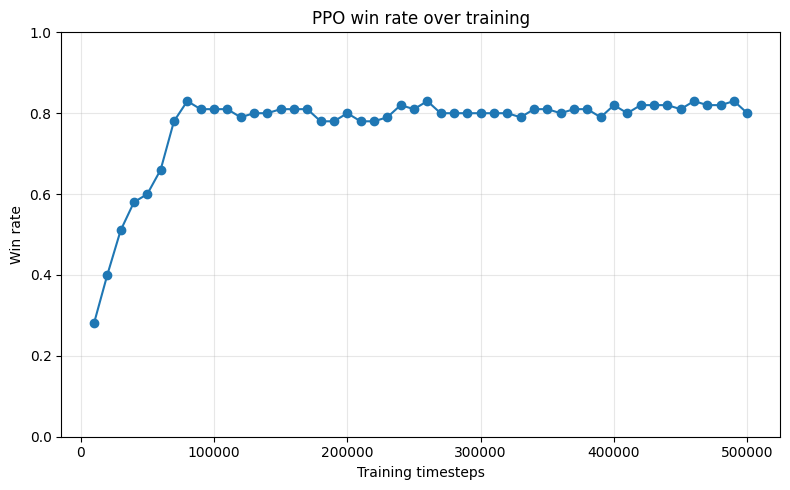

In [8]:
# main learning curve
history_df = evaluation_history_df.copy()
plt.figure(figsize=(8, 5))
plt.plot(
    history_df["timesteps"],
    history_df["win_rate"],
    marker="o",
)
plt.xlabel("Training timesteps")
plt.ylabel("Win rate")
plt.title("PPO win rate over training")
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Mean score difference vs timesteps

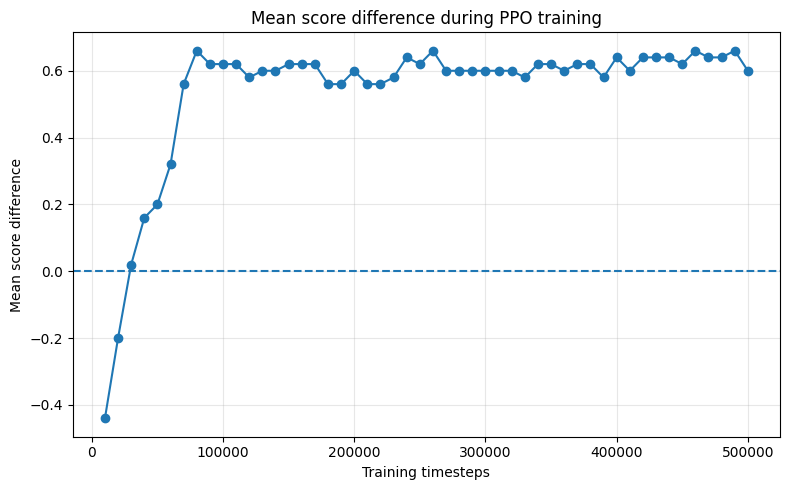

In [9]:
# transition from losing on average to winning on average
plt.figure(figsize=(8, 5))
plt.plot(
    history_df["timesteps"],
    history_df["mean_score_diff"],
    marker="o",
)
plt.axhline(0, linestyle="--")
plt.xlabel("Training timesteps")
plt.ylabel("Mean score difference")
plt.title("Mean score difference during PPO training")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Target alignment error vs timesteps

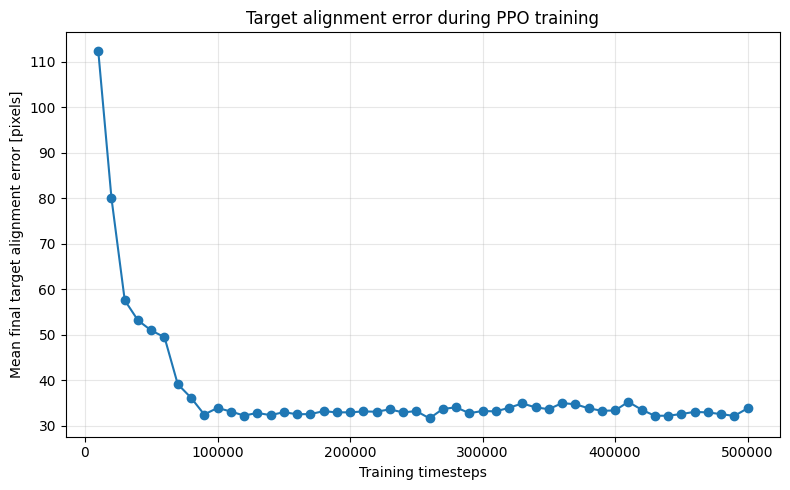

In [10]:
# agent learns the predictive target selection behavior
plt.figure(figsize=(8, 5))
plt.plot(history_df["timesteps"],history_df["mean_final_target_alignment_error"],marker="o")
plt.xlabel("Training timesteps")
plt.ylabel("Mean final target alignment error [pixels]")
plt.title("Target alignment error during PPO training")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Alignment reward vs timesteps

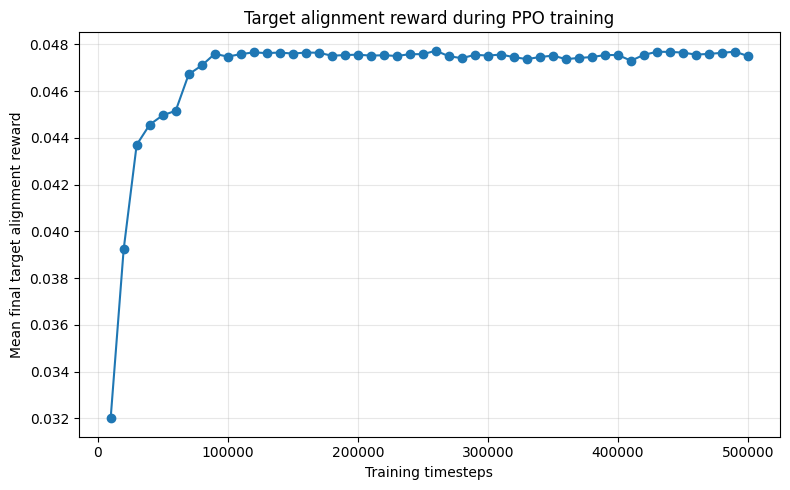

In [11]:
# policy increasingly chooses targets close to the predicted return location
plt.figure(figsize=(8, 5))
plt.plot(history_df["timesteps"],history_df["mean_final_target_alignment_reward"],marker="o")
plt.xlabel("Training timesteps")
plt.ylabel("Mean final target alignment reward")
plt.title("Target alignment reward during PPO training")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Successful returns and decision depth vs timesteps

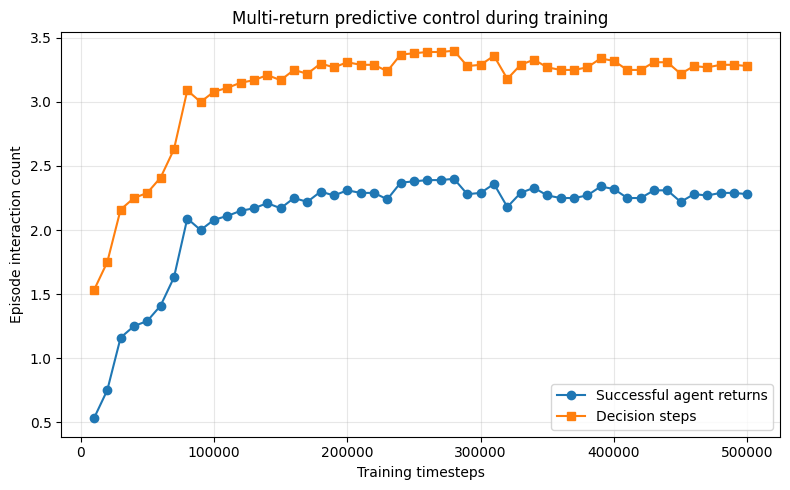

In [12]:
# PPO learns to sustain longer rallies before winning
plt.figure(figsize=(8, 5))
plt.plot(history_df["timesteps"],history_df["mean_successful_agent_returns"],marker="o",label="Successful agent returns")
plt.plot(history_df["timesteps"],history_df["mean_steps"],marker="s",label="Decision steps")
plt.xlabel("Training timesteps")
plt.ylabel("Episode interaction count")
plt.title("Multi-return predictive control during training")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Speed multiplier / outgoing speed over training

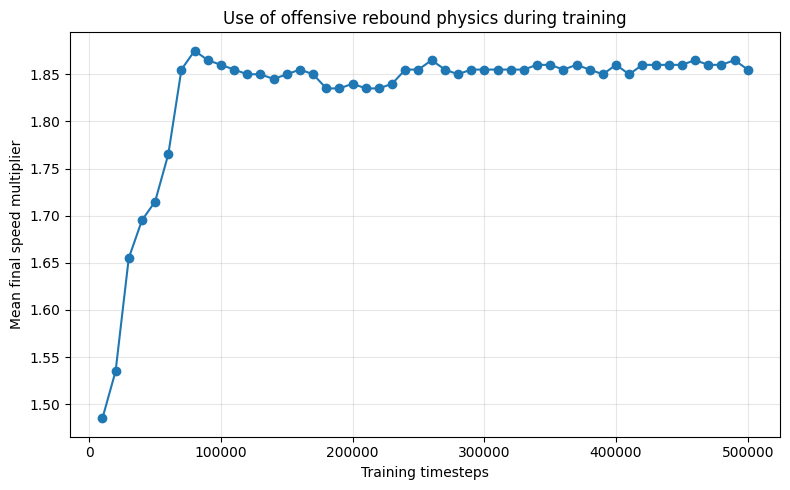

In [13]:
# agent learns to exploit the rebound physics more aggressively
plt.figure(figsize=(8, 5))
plt.plot(history_df["timesteps"],history_df["mean_final_speed_multiplier"],marker="o")
plt.xlabel("Training timesteps")
plt.ylabel("Mean final speed multiplier")
plt.title("Use of offensive rebound physics during training")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

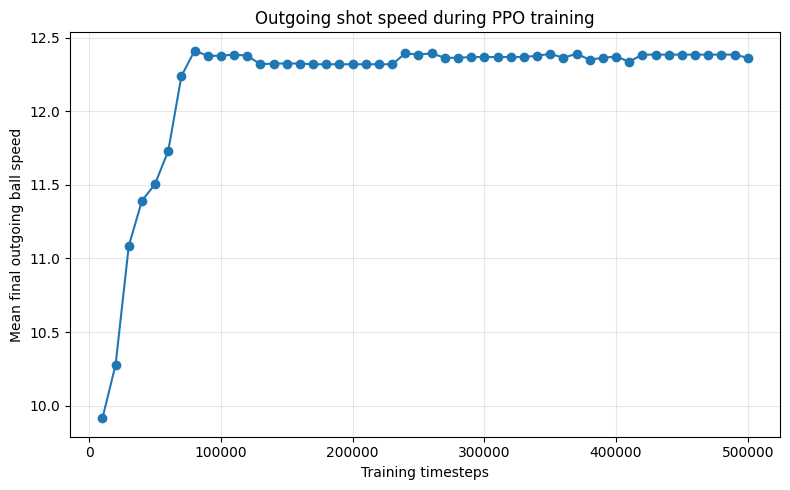

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["timesteps"],history_df["mean_final_outgoing_speed"],marker="o")
plt.xlabel("Training timesteps")
plt.ylabel("Mean final outgoing ball speed")
plt.title("Outgoing shot speed during PPO training")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# final baselines vs PPO

In [16]:
from pong_baselines import run_all_baselines
summary_df, all_details = run_all_baselines(
    n_episodes=300,
    max_episode_decisions=50,
    seed_offset=100_000,
)

Evaluating baseline: random
Evaluating baseline: center
Evaluating baseline: top
Evaluating baseline: bottom
Evaluating baseline: heuristic_predictive


In [18]:
comparison_columns = [
    "policy",
    "episodes",
    "win_rate",
    "loss_rate",
    "mean_reward",
    "mean_score_diff",
    "mean_steps",
    "mean_successful_agent_returns",
    "mean_final_target_alignment_error",
    "mean_final_target_alignment_reward",
]

final_comparison_table = (
    comparison_df[comparison_columns]
    .sort_values("win_rate", ascending=False)
    .reset_index(drop=True)
)

final_comparison_table

,policy,episodes,win_rate,loss_rate,mean_reward,mean_score_diff,mean_steps,mean_successful_agent_returns,mean_final_target_alignment_error,mean_final_target_alignment_reward
0,heuristic_predictive,300,0.996667,0.000000,1.653417,0.996667,9.723333,8.726667,14.179153,0.049529
1,ppo_stage3_final,300,0.816667,0.183333,0.827127,0.633333,3.120000,2.120000,31.543771,0.047622
2,ppo_stage3_best_by_win_rate,300,0.806667,0.193333,0.816570,0.613333,3.253333,2.253333,30.781085,0.047718
3,center,300,0.153333,0.846667,-0.651284,-0.693333,1.263333,0.263333,153.024004,0.024004
4,top,300,0.113333,0.886667,-0.752348,-0.773333,1.126667,0.126667,266.992347,0.012245
5,random,300,0.106667,0.893333,-0.760052,-0.786667,1.120000,0.120000,207.010383,0.018377
6,bottom,300,0.100000,0.900000,-0.784336,-0.800000,1.093333,0.093333,292.479725,0.009221


random or fixed baselines < PPO < heuristic upper reference

In [19]:
final_comparison_table.to_csv(
    os.path.join(LOG_DIR, "final_policy_comparison_table.csv"),
    index=False,
)

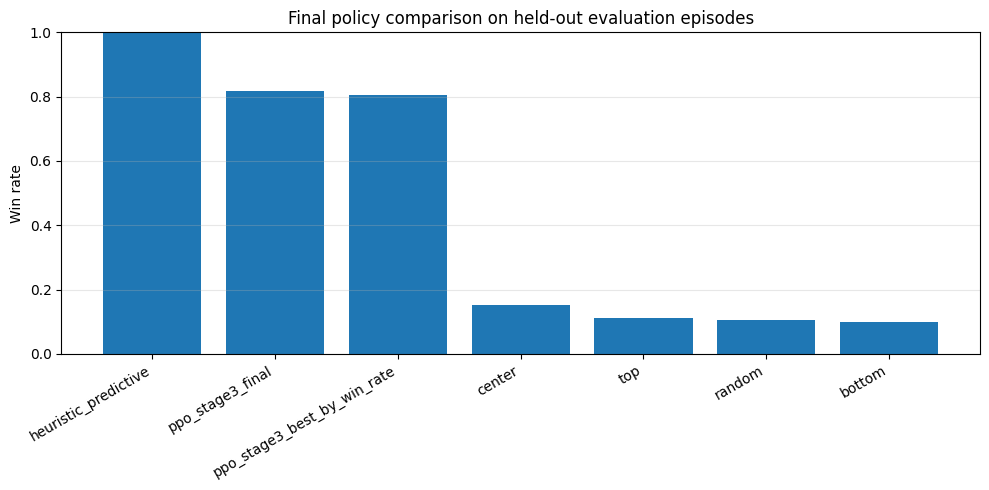

In [20]:
plot_df = comparison_df.sort_values("win_rate",ascending=False)
plt.figure(figsize=(10, 5))
plt.bar(plot_df["policy"],plot_df["win_rate"])
plt.ylabel("Win rate")
plt.title("Final policy comparison on held-out evaluation episodes")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()